In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import load_diabetes
from numdifftools import Gradient

### Задание 1

Задача:\
Решить задачу регрессии на примере следующих данных:

In [2]:
x = np.array([6.1101, 5.5277, 8.5186, 7.0032, 5.8598, 8.3829, 7.4764, 8.5781, 6.4862, 5.0546, 5.7107, 14.164, 5.734,
     8.4084, 5.6407, 5.3794,6.3654, 5.1301, 6.4296, 7.0708, 6.1891, 20.27, 5.4901, 6.3261, 5.5649, 18.945,
     12.828, 10.957, 13.176, 22.203, 5.2524, 6.5894,9.2482, 5.8918, 8.2111, 7.9334, 8.0959, 5.6063, 12.836,
     6.3534, 5.4069, 6.8825, 11.708, 5.7737, 7.8247, 7.0931, 5.0702, 5.8014,11.7, 5.5416, 7.5402, 5.3077,
     7.4239, 7.6031, 6.3328, 6.3589, 6.2742, 5.6397, 9.3102, 9.4536, 8.8254, 5.1793, 21.279, 14.908, 18.959,
     7.2182, 8.2951, 10.236, 5.4994, 20.341, 10.136, 7.3345, 6.0062, 7.2259, 5.0269, 6.5479, 7.5386, 5.0365,
     10.274, 5.1077, 5.7292, 5.1884,6.3557, 9.7687, 6.5159, 8.5172, 9.1802, 6.002, 5.5204, 5.0594, 5.7077,
     7.6366, 5.8707, 5.3054, 8.2934, 13.394, 5.4369])
y = np.array([17.592, 9.1302, 13.662, 11.854, 6.8233, 11.886, 4.3483, 12, 6.5987, 3.8166, 3.2522, 15.505, 3.1551,
     7.2258, 0.71618, 3.5129, 5.3048, 0.56077,3.6518, 5.3893, 3.1386, 21.767, 4.263, 5.1875, 3.0825, 22.638,
     13.501, 7.0467, 14.692, 24.147, -1.22, 5.9966, 12.134, 1.8495, 6.5426, 4.5623,4.1164, 3.3928, 10.117, 5.4974,
     0.55657, 3.9115, 5.3854, 2.4406, 6.7318, 1.0463, 5.1337, 1.844, 8.0043, 1.0179, 6.7504, 1.8396, 4.2885, 4.9981,
     1.4233, -1.4211, 2.4756, 4.6042, 3.9624, 5.4141, 5.1694, -0.74279, 17.929, 12.054, 17.054, 4.8852, 5.7442, 7.7754,
     .0173, 20.992, 6.6799, 4.0259,1.2784, 3.3411, -2.6807, 0.29678, 3.8845, 5.7014, 6.7526, 2.0576, 0.47953, 0.20421,
     0.67861, 7.5435, 5.3436, 4.2415, 6.7981, 0.92695, 0.152, 2.8214,1.8451, 4.2959, 7.2029, 1.9869, 0.14454, 9.0551, 0.61705])



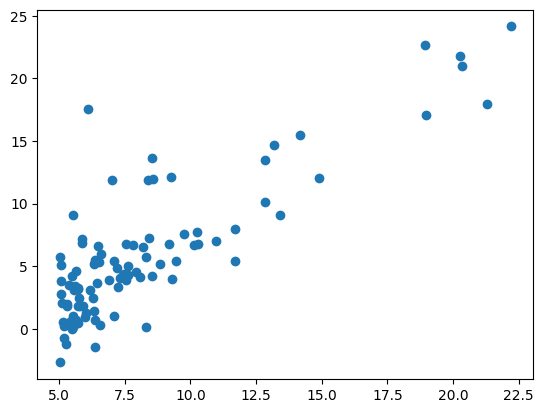

In [3]:
plt.scatter(x, y)

In [4]:
# Аналитическое решение
model = LinearRegression().fit(x.reshape(-1, 1), y)

### Задание 2


Задача:\
Написать функцию, которая реализует численное решение задачи регрессии.
Сравнить результат численного решения с аналитическим.

In [5]:
def make_loss(features, target):
  def loss_func(w):
    # Превратили вектор в матрицу
    matrix_features = np.matrix(features)
    # Добавли столбец с единицами для свободного коэффициента
    matrix_features = np.concatenate([np.ones((len(features), 1)), matrix_features], axis=1)
    #Умножили на коэффициенты модели, получили вектор предсказанных значений
    pred = np.matmul(matrix_features, w)
    #ВПревратили в вектор (это оказалось намного сложнее, чем ожидалось)
    pred = np.squeeze(np.asarray(pred))
    # Вернули ошибку
    return np.sqrt(sum((target - pred) ** 2) / len(features))
  return loss_func

def gd_regression(features, target, alpha, tol):
  loss = make_loss(features, target)
  grad = Gradient(loss)
  w_old = np.random.default_rng().integers(low=-10, high=10, size=len(features[0]) + 1)
  w_new = w_old - alpha * grad(w_old)
  while (loss(w_old) - loss(w_new)) > tol:
    #print(loss(w_new), loss(w_old))
    w_old, w_new = w_new, w_new - alpha * grad(w_old)
  return w_old
b_0, b_1 = gd_regression(x.reshape(-1, 1), y, 0.001, 0.001)

In [ ]:
def gd_reg(X, y, alpha, n_iter):
  new_col = np.ones((len(X), 1))
  X = np.hstack((new_col, X))
  w = np.random.default_rng().integers(low=-100, high=100, size=len(X[0]))
  for _ in range(n_iter):
    f = X @ w
    err = f - y
    grad = 2 * (X.T @ err) / len(X)
    w = w - alpha * grad
  return w

b_0, b_1 = gd_reg(x.reshape(-1, 1), y, 0.001, 1000)
print(b_0, b_1)

18.849703754929156 -1.0926991188836361


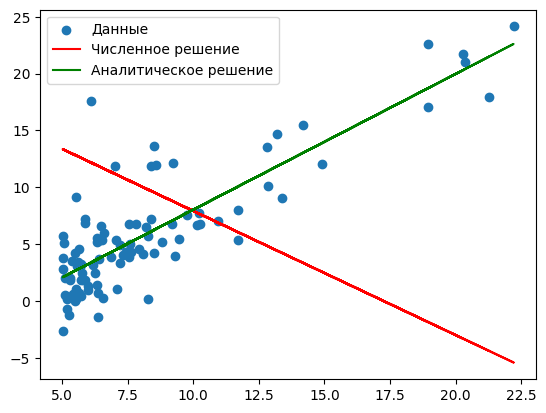

In [7]:
# Сравнение графиков
plt.scatter(x, y, label="Данные")
plt.plot(x, b_0 + b_1 * x, label="Численное решение", c="red")
plt.plot(x, model.predict(x.reshape(-1, 1)), label="Аналитическое решение", c="green")
plt.legend()

In [8]:
#Сравниваем метрики
print(f"Коэффициент детерминации аналитичсекого решения: {model.score(x.reshape(-1, 1), y)}")
print(f"Коэффициент детермниации численного решения: {r2_score(y, b_0 + b_1 * x)}")

Коэффициент детерминации аналитичсекого решения: 0.7016513979516958
Коэффициент детермниации численного решения: -2.4287074948292426


### Задание 3

Задача:\
Решить задачу регрессии для структурированных данных.
Сравнить работу линейной регрессии с Lasso-регрессией и с Ridge-регрессией.Вывести метрики оценки качества модели для задачи регрессии.

In [ ]:
# Взяли датасет про диабет (уже нормализировали)
data = load_diabetes()
X, y = data["data"], data["target"] # type: ignore

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Поcтроение обычной регрессии
base_model = LinearRegression().fit(X_train, y_train)

alpha = 0.3
# Построение лассо
lasso_model = Lasso(alpha).fit(X_train, y_train)

# Построение гребня
ridge_model = Ridge(alpha).fit(X_train, y_train)

In [10]:
# Сравнение трёх регрессий

# Метрики
print(f"Коэффициент детерминации обычной регрессии: {base_model.score(X_test, y_test)}")
print(f"Коэффициент детерминации лассо регрессии: {lasso_model.score(X_test, y_test)}")
print(f"Коэффициент детерминации гребневой регрессии: {ridge_model.score(X_test, y_test)}")

# Коэффициенты
display(pd.DataFrame({"Base": base_model.coef_, "Lasso": lasso_model.coef_, "Ridge": ridge_model.coef_}, index=data.feature_names))


Коэффициент детерминации обычной регрессии: 0.47818143565098226
Коэффициент детерминации лассо регрессии: 0.39260320113409064
Коэффициент детерминации гребневой регрессии: 0.44344078461060954


,Base,Lasso,Ridge
age,-8.647311,0.000000,13.307791
sex,-208.666310,-0.000000,-131.927370
bmi,520.237780,504.162545,410.651899
bp,260.706309,128.463414,222.681819
s1,-625.682530,-0.000000,-5.752043
s2,382.346076,-0.000000,-66.681901
s3,45.290331,-68.519559,-161.451514
s4,91.616913,0.000000,99.463732
s5,734.436322,472.398204,370.864492
s6,73.567903,0.000000,101.952764
